In [ ]:
#@title Installing python dependencies
%%capture
!pip install python-dotenv langchain[docarray] openai tiktoken faiss-cpu pypdf yt_dlp pydub chromadb -q

In [ ]:
#@title To Environment keys { display-mode: "form" }
#@markdown Add your OPEN-API-KEY from [openai](https://openai.com/blog/openai-api)

openai_key = 'sk-'  #@param {type: "string"}

with open(".env", "w") as f:
    f.write(f"OPENAI_API_KEY={openai_key}\n")

print("Overwriting .env")

from dotenv import load_dotenv
_=load_dotenv()

Overwriting .env


# Document Loading

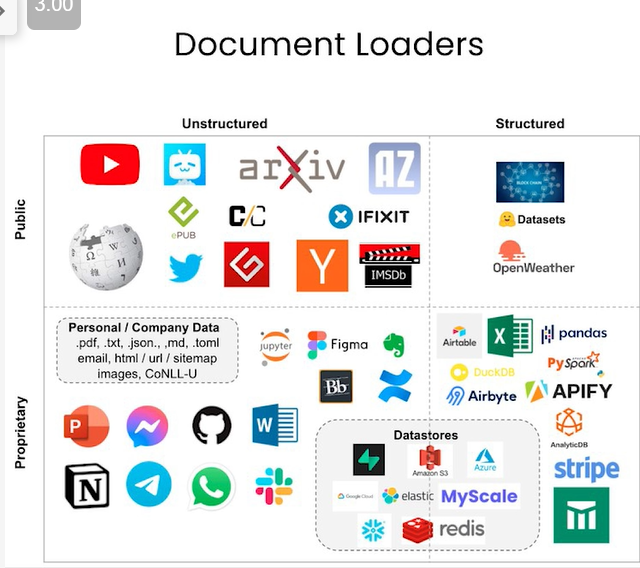

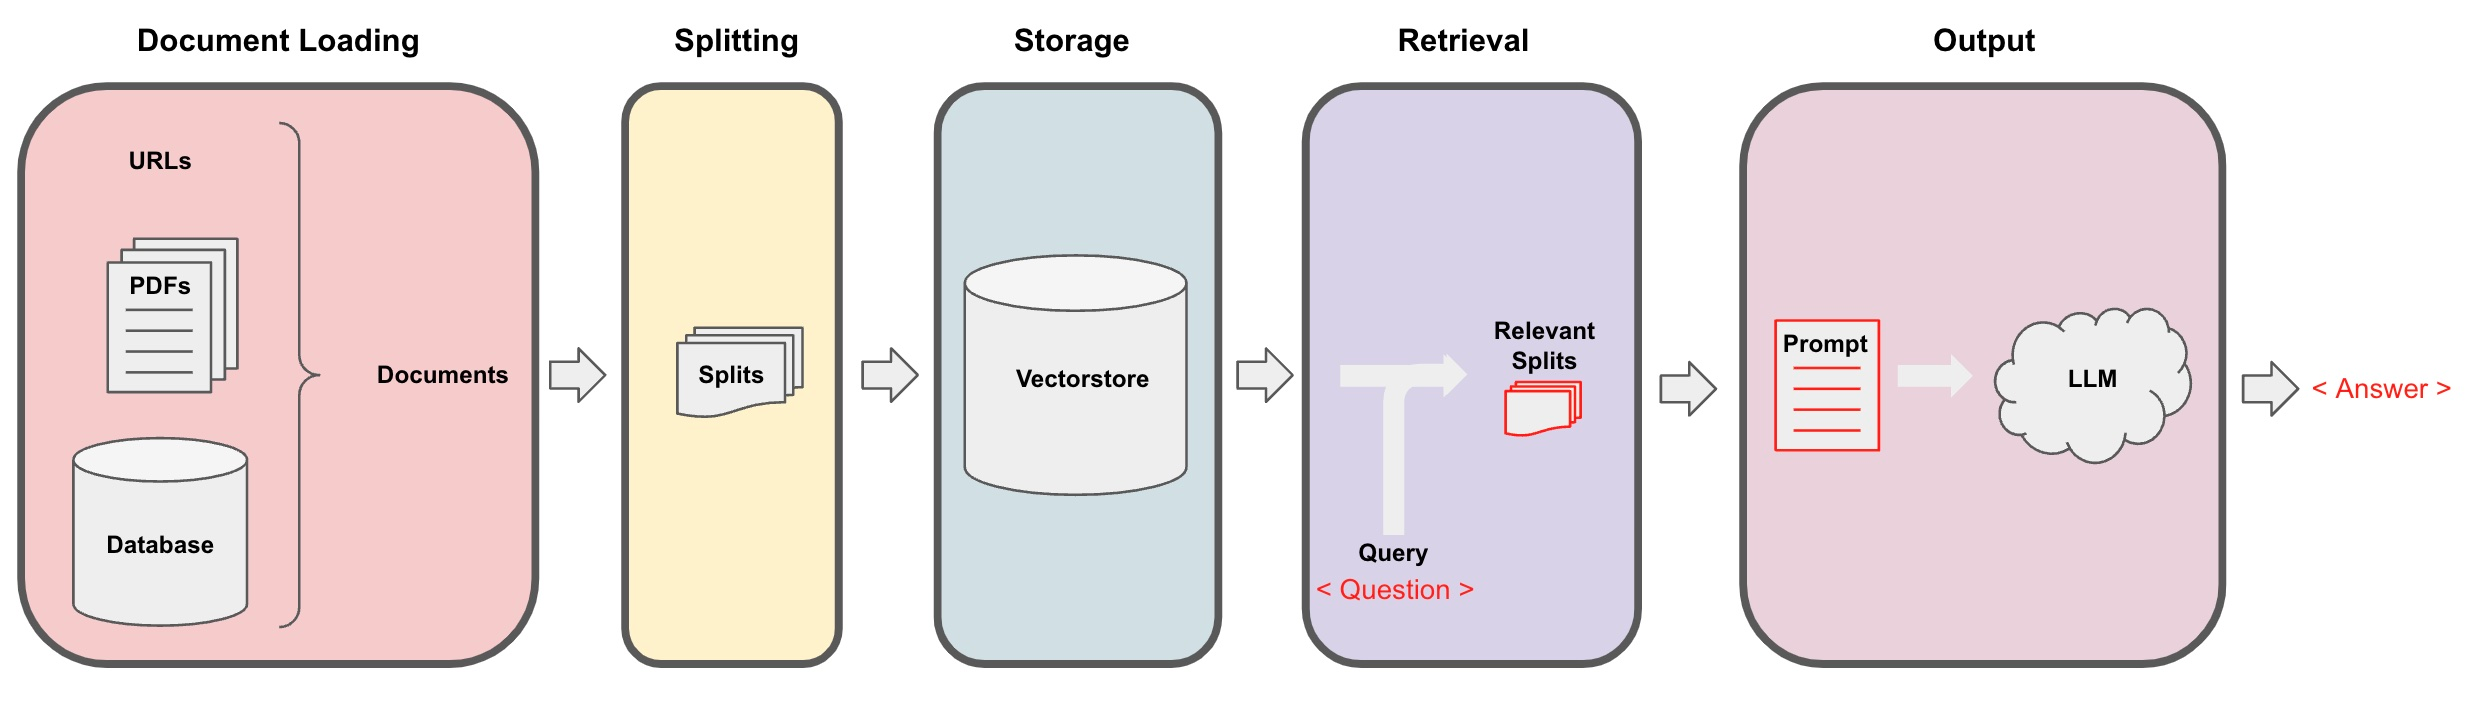

In [ ]:
import os
import openai
import sys
sys.path.append('../..')

from dotenv import load_dotenv, find_dotenv
_ = load_dotenv(find_dotenv()) # read local .env file

openai.api_key  = os.environ['OPENAI_API_KEY']

In [ ]:
%mkdir docs/
%mkdir docs/pdfs/
!wget https://cs229.stanford.edu/main_notes.pdf -O docs/pdfs/machine-learning.pdf

mkdir: cannot create directory ‘docs/’: File exists
mkdir: cannot create directory ‘docs/pdfs/’: File exists
--2023-07-05 17:52:11--  https://cs229.stanford.edu/main_notes.pdf
Resolving cs229.stanford.edu (cs229.stanford.edu)... 171.64.64.64
Connecting to cs229.stanford.edu (cs229.stanford.edu)|171.64.64.64|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3401557 (3.2M) [application/pdf]
Saving to: ‘docs/pdfs/machine-learning.pdf’

docs/pdfs/machine-l 100%[===================>]   3.24M  2.69MB/s    in 1.2s    

2023-07-05 17:52:13 (2.69 MB/s) - ‘docs/pdfs/machine-learning.pdf’ saved [3401557/3401557]



In [ ]:
from langchain.document_loaders import PyPDFLoader
loader = PyPDFLoader("docs/pdfs/machine-learning.pdf")
pages = loader.load()

In [ ]:
len(pages)

227

In [ ]:
page = pages[0]

In [ ]:
print(page.page_content[0:500])

CS229 Lecture Notes
Andrew Ng and Tengyu Ma
June 11, 2023


In [ ]:
page.metadata

{'source': 'docs/pdfs/machine-learning.pdf', 'page': 0}

In [ ]:
from langchain.document_loaders.generic import GenericLoader
from langchain.document_loaders.parsers import OpenAIWhisperParser
from langchain.document_loaders.blob_loaders.youtube_audio import YoutubeAudioLoader

In [ ]:
url="https://www.youtube.com/watch?v=jGwO_UgTS7I"
save_dir="docs/youtube/"
loader = GenericLoader(
    YoutubeAudioLoader([url],save_dir),
    OpenAIWhisperParser()
)
docs = loader.load()

[youtube] Extracting URL: https://www.youtube.com/watch?v=jGwO_UgTS7I
[youtube] jGwO_UgTS7I: Downloading webpage
[youtube] jGwO_UgTS7I: Downloading ios player API JSON
[youtube] jGwO_UgTS7I: Downloading android player API JSON
[youtube] jGwO_UgTS7I: Downloading m3u8 information
[info] jGwO_UgTS7I: Downloading 1 format(s): 140
[download] Destination: docs/youtube//Stanford CS229： Machine Learning Course, Lecture 1 - Andrew Ng (Autumn 2018).m4a
[download] 100% of   69.76MiB in 00:00:01 at 38.98MiB/s  
[FixupM4a] Correcting container of "docs/youtube//Stanford CS229： Machine Learning Course, Lecture 1 - Andrew Ng (Autumn 2018).m4a"
[ExtractAudio] Not converting audio docs/youtube//Stanford CS229： Machine Learning Course, Lecture 1 - Andrew Ng (Autumn 2018).m4a; file is already in target format m4a
Transcribing part 1!


AuthenticationError: ignored

In [ ]:
docs[0].page_content[0:500]

In [ ]:
from langchain.document_loaders import WebBaseLoader

loader = WebBaseLoader("https://github.com/basecamp/handbook/blob/master/37signals-is-you.md")

In [ ]:
docs = loader.load()

In [ ]:
print(docs[0].page_content[:500])






























































handbook/37signals-is-you.md at master · basecamp/handbook · GitHub

















































Skip to content







Toggle navigation










            Sign up
          


 













        Product
        












Actions
        Automate any workflow
      







Packages
        Host and manage packages
      







Security
        Find and fix vulnerabilities
      







Codespaces
       


Follow steps [here](https://python.langchain.com/docs/modules/data_connection/document_loaders/integrations/notion) for an example Notion site such as [this one](https://yolospace.notion.site/Blendle-s-Employee-Handbook-e31bff7da17346ee99f531087d8b133f):

* Duplicate the page into your own Notion space and export as `Markdown / CSV`.
* Unzip it and save it as a folder that contains the markdown file for the Notion page.


In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  name = fn

Saving 14317691-4535-4b12-a7be-321c4c001af2_Export-d4d262a1-8867-4501-917a-3cafdd54c5c6.zip to 14317691-4535-4b12-a7be-321c4c001af2_Export-d4d262a1-8867-4501-917a-3cafdd54c5c6.zip
User uploaded file "14317691-4535-4b12-a7be-321c4c001af2_Export-d4d262a1-8867-4501-917a-3cafdd54c5c6.zip" with length 2823 bytes


In [ ]:
!unzip {name}  -d docs/Notion_DB

Archive:  14317691-4535-4b12-a7be-321c4c001af2_Export-d4d262a1-8867-4501-917a-3cafdd54c5c6.zip
  inflating: docs/Notion_DB/Blendle's Employee Handbook f8b741cc76a9454b9349a78df739ef67.md  


In [ ]:
from langchain.document_loaders import NotionDirectoryLoader
loader = NotionDirectoryLoader("docs/Notion_DB")
docs = loader.load()

In [ ]:
print(docs[0].page_content[0:200])

# Blendle's Employee Handbook

This is a living document with everything we've learned working with people while running a startup. And, of course, we continue to learn. Therefore it's a document that


In [ ]:
docs[0].metadata

{'source': "docs/Notion_DB/Blendle's Employee Handbook f8b741cc76a9454b9349a78df739ef67.md"}

# Document Splitting

In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter, CharacterTextSplitter

In [ ]:
chunk_size =26
chunk_overlap = 4

In [ ]:
r_splitter = RecursiveCharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap
)
c_splitter = CharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap
)

In [ ]:
# Why doesn't this split the string below?
text1 = 'abcdefghijklmnopqrstuvwxyz'
r_splitter.split_text(text1)

['abcdefghijklmnopqrstuvwxyz']

In [ ]:
text2 = 'abcdefghijklmnopqrstuvwxyzabcdefg'
r_splitter.split_text(text2)

['abcdefghijklmnopqrstuvwxyz', 'wxyzabcdefg']

In [ ]:
text3 = "a b c d e f g h i j k l m n o p q r s t u v w x y z"

In [ ]:
r_splitter.split_text(text3)

['a b c d e f g h i j k l m', 'l m n o p q r s t u v w x', 'w x y z']

In [ ]:
c_splitter.split_text(text3)

['a b c d e f g h i j k l m n o p q r s t u v w x y z']

In [ ]:
c_splitter = CharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap,
    separator = ' '
)
c_splitter.split_text(text3)

['a b c d e f g h i j k l m', 'l m n o p q r s t u v w x', 'w x y z']

In [ ]:
some_text = """When writing documents, writers will use document structure to group content. \
This can convey to the reader, which idea's are related. For example, closely related ideas \
are in sentances. Similar ideas are in paragraphs. Paragraphs form a document. \n\n  \
Paragraphs are often delimited with a carriage return or two carriage returns. \
Carriage returns are the "backslash n" you see embedded in this string. \
Sentences have a period at the end, but also, have a space.\
and words are separated by space."""

In [ ]:
len(some_text)

496

In [ ]:
c_splitter = CharacterTextSplitter(
    chunk_size=450,
    chunk_overlap=0,
    separator = ' '
)
r_splitter = RecursiveCharacterTextSplitter(
    chunk_size=450,
    chunk_overlap=0,
    separators=["\n\n", "\n", " ", ""]
)

In [ ]:
c_splitter.split_text(some_text)

['When writing documents, writers will use document structure to group content. This can convey to the reader, which idea\'s are related. For example, closely related ideas are in sentances. Similar ideas are in paragraphs. Paragraphs form a document. \n\n Paragraphs are often delimited with a carriage return or two carriage returns. Carriage returns are the "backslash n" you see embedded in this string. Sentences have a period at the end, but also,',
 'have a space.and words are separated by space.']

In [ ]:
r_splitter.split_text(some_text)

["When writing documents, writers will use document structure to group content. This can convey to the reader, which idea's are related. For example, closely related ideas are in sentances. Similar ideas are in paragraphs. Paragraphs form a document.",
 'Paragraphs are often delimited with a carriage return or two carriage returns. Carriage returns are the "backslash n" you see embedded in this string. Sentences have a period at the end, but also, have a space.and words are separated by space.']

In [ ]:
r_splitter = RecursiveCharacterTextSplitter(
    chunk_size=150,
    chunk_overlap=0,
    separators=["\n\n", "\n", "\. ", " ", ""]
)
r_splitter.split_text(some_text)

["When writing documents, writers will use document structure to group content. This can convey to the reader, which idea's are related",
 '. For example, closely related ideas are in sentances. Similar ideas are in paragraphs. Paragraphs form a document.',
 'Paragraphs are often delimited with a carriage return or two carriage returns',
 '. Carriage returns are the "backslash n" you see embedded in this string',
 '. Sentences have a period at the end, but also, have a space.and words are separated by space.']

In [ ]:
r_splitter = RecursiveCharacterTextSplitter(
    chunk_size=150,
    chunk_overlap=0,
    separators=["\n\n", "\n", "(?<=\. )", " ", ""]
)
r_splitter.split_text(some_text)

["When writing documents, writers will use document structure to group content. This can convey to the reader, which idea's are related.",
 'For example, closely related ideas are in sentances. Similar ideas are in paragraphs. Paragraphs form a document.',
 'Paragraphs are often delimited with a carriage return or two carriage returns.',
 'Carriage returns are the "backslash n" you see embedded in this string.',
 'Sentences have a period at the end, but also, have a space.and words are separated by space.']

Check that now its splited better, The first document ends with '.' and the second one start with Upper case.

In [ ]:
from langchain.document_loaders import PyPDFLoader
loader = PyPDFLoader("docs/pdfs/machine-learning.pdf")
pages = loader.load()

In [ ]:
from langchain.text_splitter import CharacterTextSplitter
text_splitter = CharacterTextSplitter(
    separator="\n",
    chunk_size=1000,
    chunk_overlap=150,
    length_function=len
)

In [ ]:
docs = text_splitter.split_documents(pages)

In [ ]:
len(docs)

513

In [ ]:
len(pages)

227

In [ ]:
from langchain.document_loaders import NotionDirectoryLoader
loader = NotionDirectoryLoader("docs/Notion_DB")
notion_db = loader.load()

In [ ]:
docs = text_splitter.split_documents(notion_db)

In [ ]:
len(notion_db)

1

In [ ]:
len(docs)

7

In [ ]:
# Token Splitting
from langchain.text_splitter import TokenTextSplitter
text_splitter = TokenTextSplitter(chunk_size=1, chunk_overlap=0)

In [ ]:
text1 = "foo bar bazzyfoo"

In [ ]:
text_splitter.split_text(text1)

['foo', ' bar', ' b', 'az', 'zy', 'foo']

## Token splitting

We can also split on token count explicity, if we want.

This can be useful because LLMs often have context windows designated in tokens.

Tokens are often ~4 characters.

In [ ]:
text_splitter = TokenTextSplitter(chunk_size=10, chunk_overlap=0)

In [ ]:
docs = text_splitter.split_documents(pages)

In [ ]:
docs[0]

Document(page_content='CS229 Lecture Notes\nAndrew Ng and Ten', metadata={'source': 'docs/pdfs/machine-learning.pdf', 'page': 0})

In [ ]:
docs[0].metadata

{'source': 'docs/pdfs/machine-learning.pdf', 'page': 0}

## Context aware splitting

Chunking aims to keep text with common context together.

A text splitting often uses sentences or other delimiters to keep related text together but many documents (such as Markdown) have structure (headers) that can be explicitly used in splitting.

We can use `MarkdownHeaderTextSplitter` to preserve header metadata in our chunks, as show below.

In [ ]:
from langchain.document_loaders import NotionDirectoryLoader
from langchain.text_splitter import MarkdownHeaderTextSplitter

In [ ]:
markdown_document = """# Title\n\n \
## Chapter 1\n\n \
Hi this is Jim\n\n Hi this is Joe\n\n \
### Section \n\n \
Hi this is Lance \n\n
## Chapter 2\n\n \
Hi this is Molly"""

In [ ]:
headers_to_split_on = [
    ("#", "Header 1"),
    ("##", "Header 2"),
    ("###", "Header 3"),
]

In [ ]:
markdown_splitter = MarkdownHeaderTextSplitter(
    headers_to_split_on=headers_to_split_on
)
md_header_splits = markdown_splitter.split_text(markdown_document)

In [ ]:
md_header_splits[0]

Document(page_content='Hi this is Jim  \nHi this is Joe', metadata={'Header 1': 'Title', 'Header 2': 'Chapter 1'})

In [ ]:
md_header_splits[1]

Document(page_content='Hi this is Lance', metadata={'Header 1': 'Title', 'Header 2': 'Chapter 1', 'Header 3': 'Section'})

In [ ]:
loader = NotionDirectoryLoader("docs/Notion_DB")
docs = loader.load()
txt = ' '.join([d.page_content for d in docs])

In [ ]:
txt

"# Blendle's Employee Handbook\n\nThis is a living document with everything we've learned working with people while running a startup. And, of course, we continue to learn. Therefore it's a document that will continue to change. \n\n**Everything related to working at Blendle and the people of Blendle, made public.**\n\nThese are the lessons from three years of working with the people of Blendle. It contains everything from [how our leaders lead](https://www.notion.so/ecfb7e647136468a9a0a32f1771a8f52?pvs=21) to [how we increase salaries](https://www.notion.so/Salary-Review-e11b6161c6d34f5c9568bb3e83ed96b6?pvs=21), from [how we hire](https://www.notion.so/Hiring-451bbcfe8d9b49438c0633326bb7af0a?pvs=21) and [fire](https://www.notion.so/Firing-5567687a2000496b8412e53cd58eed9d?pvs=21) to [how we think people should give each other feedback](https://www.notion.so/Our-Feedback-Process-eb64f1de796b4350aeab3bc068e3801f?pvs=21) — and much more.\n\nWe've made this document public because we want 

In [ ]:
headers_to_split_on = [
    ("#", "Header 1"),
    ("##", "Header 2"),
]
markdown_splitter = MarkdownHeaderTextSplitter(
    headers_to_split_on=headers_to_split_on
)

In [ ]:
md_header_splits = markdown_splitter.split_text(txt)

In [ ]:
import pprint
pprint.pprint(md_header_splits)

[Document(page_content="This is a living document with everything we've learned working with people while running a startup. And, of course, we continue to learn. Therefore it's a document that will continue to change.  \n**Everything related to working at Blendle and the people of Blendle, made public.**  \nThese are the lessons from three years of working with the people of Blendle. It contains everything from [how our leaders lead](https://www.notion.so/ecfb7e647136468a9a0a32f1771a8f52?pvs=21) to [how we increase salaries](https://www.notion.so/Salary-Review-e11b6161c6d34f5c9568bb3e83ed96b6?pvs=21), from [how we hire](https://www.notion.so/Hiring-451bbcfe8d9b49438c0633326bb7af0a?pvs=21) and [fire](https://www.notion.so/Firing-5567687a2000496b8412e53cd58eed9d?pvs=21) to [how we think people should give each other feedback](https://www.notion.so/Our-Feedback-Process-eb64f1de796b4350aeab3bc068e3801f?pvs=21) — and much more.  \nWe've made this document public because we want to learn fr

In [ ]:
md_header_splits[0]

Document(page_content="This is a living document with everything we've learned working with people while running a startup. And, of course, we continue to learn. Therefore it's a document that will continue to change.  \n**Everything related to working at Blendle and the people of Blendle, made public.**  \nThese are the lessons from three years of working with the people of Blendle. It contains everything from [how our leaders lead](https://www.notion.so/ecfb7e647136468a9a0a32f1771a8f52?pvs=21) to [how we increase salaries](https://www.notion.so/Salary-Review-e11b6161c6d34f5c9568bb3e83ed96b6?pvs=21), from [how we hire](https://www.notion.so/Hiring-451bbcfe8d9b49438c0633326bb7af0a?pvs=21) and [fire](https://www.notion.so/Firing-5567687a2000496b8412e53cd58eed9d?pvs=21) to [how we think people should give each other feedback](https://www.notion.so/Our-Feedback-Process-eb64f1de796b4350aeab3bc068e3801f?pvs=21) — and much more.  \nWe've made this document public because we want to learn fro

## Vectorstores and Embeddings¶

Recall the overall workflow for retrieval augmented generation (RAG):


In [ ]:
from langchain.document_loaders import PyPDFLoader

# Load PDF
loaders = [
    # Duplicate documents on purpose - messy data
    PyPDFLoader("docs/pdfs/machine-learning.pdf")
]
docs = []
for loader in loaders:
    docs.extend(loader.load())

In [ ]:
# Split
from langchain.text_splitter import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1500,
    chunk_overlap = 150
)

In [ ]:
splits = text_splitter.split_documents(docs)

In [ ]:
len(splits)

375

In [ ]:
## Embeddings
from langchain.embeddings.openai import OpenAIEmbeddings
embedding = OpenAIEmbeddings()

In [ ]:
sentence1 = "i like dogs"
sentence2 = "i like canines"
sentence3 = "the weather is ugly outside"

In [ ]:
embedding1 = embedding.embed_query(sentence1)
embedding2 = embedding.embed_query(sentence2)
embedding3 = embedding.embed_query(sentence3)

In [ ]:
import numpy as np
np.dot(embedding1, embedding2)

0.9631853877103518

In [ ]:
np.dot(embedding1, embedding3)

0.7709997651294672

In [ ]:
np.dot(embedding2, embedding3)

0.7596334120325523

In [ ]:
from langchain.vectorstores import Chroma
persist_directory = 'docs/chroma/'
!rm -rf ./docs/chroma  # remove old database files if any

In [ ]:
vectordb = Chroma.from_documents(
    documents=splits,
    embedding=embedding,
    persist_directory=persist_directory
)

In [ ]:
print(vectordb._collection.count())

375


## Similarity Search

In [ ]:
question = "is there an email i can ask for help"

In [ ]:
docs = vectordb.similarity_search(question,k=3)

In [ ]:
len(docs)

3

In [ ]:
docs[0].page_content

'representing emails. We let xjdenote the identity of the j-th word in the\nemail. Thus, xjis now an integer taking values in f1;:::;jVjg, wherejVj\nis the size of our vocabulary (dictionary). An email of dwords is now rep-\nresented by a vector ( x1;x2;:::;xd) of length d; note that dcan vary for\ndi\x0berent documents. For instance, if an email starts with \\A NeurIPS . . . ,"\nthenx1= 1 (\\a" is the \x0crst word in the dictionary), and x2= 35000 (if\n\\neurips" is the 35000th word in the dictionary).\nIn the multinomial event model, we assume that the way an email is\ngenerated is via a random process in which spam/non-spam is \x0crst deter-\nmined (according to p(y)) as before. Then, the sender of the email writes the\nemail by \x0crst generating x1from some multinomial distribution over words\n(p(x1jy)). Next, the second word x2is chosen independently of x1but from\nthe same multinomial distribution, and similarly for x3,x4, and so on, until\nalldwords of the email have been gener

In [ ]:
vectordb.persist()

## Failure modes

This seems great, and basic similarity search will get you 80% of the way there very easily.

But there are some failure modes that can creep up.

Here are some edge cases that can arise - we'll fix them in the next class.

In [ ]:
question = "what did they say about matlab?"

In [ ]:
docs = vectordb.similarity_search(question,k=5)

In [ ]:
docs[0]

Document(page_content='58\nApplication of kernel methods: We\'ve seen the application of kernels\nto linear regression. In the next part, we will introduce the support vector\nmachines to which kernels can be directly applied. dwell too much longer on\nit here. In fact, the idea of kernels has signi\x0ccantly broader applicability than\nlinear regression and SVMs. Speci\x0ccally, if you have any learning algorithm\nthat you can write in terms of only inner products hx;zibetween input\nattribute vectors, then by replacing this with K(x;z) whereKis a kernel,\nyou can \\magically" allow your algorithm to work e\x0eciently in the high\ndimensional feature space corresponding to K. For instance, this kernel trick\ncan be applied with the perceptron to derive a kernel perceptron algorithm.\nMany of the algorithms that we\'ll see later in this class will also be amenable\nto this method, which has come to be known as the \\kernel trick."', metadata={'source': 'docs/pdfs/machine-learning.pdf',

In [ ]:
docs[1]

Document(page_content='a good tradeo\x0b between the twin evils of bias and variance5? Alternatively,\nsuppose we want to automatically choose the bandwidth parameter \x1cfor\nlocally weighted regression, or the parameter Cfor our`1-regularized SVM.\nHow can we do that?\nFor the sake of concreteness, in these notes we assume we have some\n\x0cnite set of models M=fM1;:::;Mdgthat we\'re trying to select among.\nFor instance, in our \x0crst example above, the model Miwould be an i-th\ndegree polynomial regression model. (The generalization to in\x0cnite Mis\nnot hard.6) Alternatively, if we are trying to decide between using an SVM,\na neural network or logistic regression, then Mmay contain these models.\n5Given that we said in the previous set of notes that bias and variance are two very\ndi\x0berent beasts, some readers may be wondering if we should be calling them \\twin" evils\nhere. Perhaps it\'d be better to think of them as non-identical twins. The phrase \\the\nfraternal twin ev

In [ ]:
question = "what did they say about regression in the third lecture?"

In [ ]:
docs = vectordb.similarity_search(question,k=5)

In [ ]:
for doc in docs:
    print(doc.metadata)

{'source': 'docs/pdfs/machine-learning.pdf', 'page': 112}
{'source': 'docs/pdfs/machine-learning.pdf', 'page': 8}
{'source': 'docs/pdfs/machine-learning.pdf', 'page': 225}
{'source': 'docs/pdfs/machine-learning.pdf', 'page': 114}
{'source': 'docs/pdfs/machine-learning.pdf', 'page': 17}


In [ ]:
print(docs[4].page_content)

1.4 Locally weighted linear regression (optional
reading)
Consider the problem of predicting yfromx2R. The leftmost gure below
shows the result of tting a y=0+1xto a dataset. We see that the data
doesn't really lie on straight line, and so the t is not very good.


# Retrieval

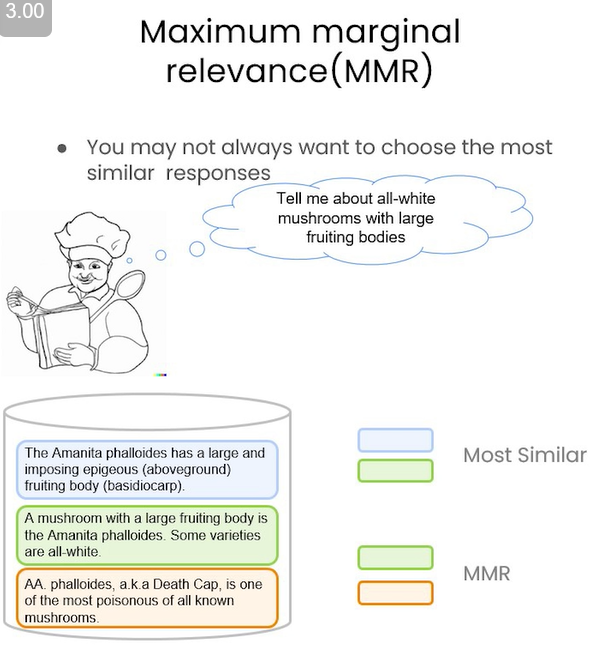

In [ ]:
from langchain.vectorstores import Chroma
from langchain.embeddings.openai import OpenAIEmbeddings
persist_directory = 'docs/chroma/'

In [ ]:
embedding = OpenAIEmbeddings()
vectordb = Chroma(
    persist_directory=persist_directory,
    embedding_function=embedding
)

In [ ]:
print(vectordb._collection.count())

375


In [ ]:
texts = [
    """The Amanita phalloides has a large and imposing epigeous (aboveground) fruiting body (basidiocarp).""",
    """A mushroom with a large fruiting body is the Amanita phalloides. Some varieties are all-white.""",
    """A. phalloides, a.k.a Death Cap, is one of the most poisonous of all known mushrooms.""",
]

In [ ]:
smalldb = Chroma.from_texts(texts, embedding=embedding)

In [ ]:
question = "Tell me about all-white mushrooms with large fruiting bodies"

In [ ]:
smalldb.similarity_search(question, k=2)

[Document(page_content='A mushroom with a large fruiting body is the Amanita phalloides. Some varieties are all-white.', metadata={}),
 Document(page_content='The Amanita phalloides has a large and imposing epigeous (aboveground) fruiting body (basidiocarp).', metadata={})]

In [ ]:
smalldb.max_marginal_relevance_search(question,k=2, fetch_k=3)

[Document(page_content='A mushroom with a large fruiting body is the Amanita phalloides. Some varieties are all-white.', metadata={}),
 Document(page_content='A. phalloides, a.k.a Death Cap, is one of the most poisonous of all known mushrooms.', metadata={})]

`Maximum marginal relevance` strives to achieve both relevance to the query *and diversity* among the results.

In [ ]:
question = "what did they say about matlab?"
docs_ss = vectordb.similarity_search(question,k=3)

In [ ]:
docs_ss[0].page_content[:100]

"58\nApplication of kernel methods: We've seen the application of kernels\nto linear regression. In the"

In [ ]:
docs_ss[1].page_content[:100]

'a good tradeo\x0b between the twin evils of bias and variance5? Alternatively,\nsuppose we want to autom'

In [ ]:
docs_mmr = vectordb.max_marginal_relevance_search(question,k=3)

In [ ]:
docs_mmr[0].page_content[:100]

"58\nApplication of kernel methods: We've seen the application of kernels\nto linear regression. In the"

In [ ]:
docs_mmr[1].page_content[:100]

'173\nsame factor; but this usually does not matter. (These comments also apply\nto ICA for the brain/M'

## working with metadata

In last lecture, we showed that a question about the third lecture can include results from other lectures as well.

To address this, many vectorstores support operations on metadata.

metadata provides context for each embedded chunk.

In [ ]:
question = "what did they say about regression in the third lecture?"

In [ ]:
# Select the root of the source
docs = vectordb.similarity_search(
    question,
    k=3,
    filter={"source":"docs/pdfs/machine-learning.pdf"}
)

In [ ]:
for d in docs:
    print(d.metadata)

{'source': 'docs/pdfs/machine-learning.pdf', 'page': 112}
{'source': 'docs/pdfs/machine-learning.pdf', 'page': 8}
{'source': 'docs/pdfs/machine-learning.pdf', 'page': 225}


### Addressing Specificity: working with metadata using self-query retriever

But we have an interesting challenge: we often want to infer the metadata from the query itself.

To address this, we can use `SelfQueryRetriever`, which uses an LLM to extract:

1. The `query` string to use for vector search
2. A metadata filter to pass in as well

Most vector databases support metadata filters, so this doesn't require any new databases or indexes.

In [ ]:
question = "what did they say about regression in the third lecture?"

In [ ]:
from langchain.llms import OpenAI
from langchain.retrievers.self_query.base import SelfQueryRetriever
from langchain.chains.query_constructor.base import AttributeInfo

In [ ]:
metadata_field_info = [
    AttributeInfo(
        name="source",
        description="The lecture the chunk is from, should be one of `docs/pdfs/machine-learning.pdf`, `` or ``",
        type="string",
    ),
    AttributeInfo(
        name="page",
        description="The page from the lecture",
        type="integer",
    ),
]

In [ ]:
# CRASH FOR TypeError: 'NoneType' object is not callable
# document_content_description = "Lecture notes"
# llm = OpenAI(temperature=0)
# retriever = SelfQueryRetriever.from_llm(
#     llm,
#     vectordb,
#     document_content_description,
#     metadata_field_info,
#     verbose=True
# )

In [ ]:
from langchain.retrievers import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import LLMChainExtractor

In [ ]:
def pretty_print_docs(docs):
    print(f"\n{'-' * 100}\n".join([f"Document {i+1}:\n\n" + d.page_content for i, d in enumerate(docs)]))


In [ ]:
# Wrap our vectorstore
llm = OpenAI(temperature=0)
compressor = LLMChainExtractor.from_llm(llm)

In [ ]:
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=vectordb.as_retriever()
)

In [ ]:
compressed_docs = compression_retriever.get_relevant_documents(question)
pretty_print_docs(compressed_docs)

Document 1:

"For instance, x(i)1is the living area of the i-th house in the training set, and x(i)2is its number of bedrooms. [...] let's say we decide to approximate yas a linear function of x: h(x) =0+1x1+2x2"


In [ ]:
import pprint
pprint.pprint(compressed_docs)

[Document(page_content='"All the deep learning packages or implementations put the data points in the rows of a data matrix." "In the example above, using the row major convention, the data matrix is X2R3\x02d, the \x0crst layer weight matrix has dimensionality d\x02m(instead of m\x02das in the two layer neural net section), and the bias vector b[1]2R1\x02m." "The computation for the hidden activation becomes Z[1]=XW[1]+b[1]2R3\x02m(7.84)"', metadata={'source': 'docs/pdfs/machine-learning.pdf', 'page': 111})]


## Combining various techniques

In [ ]:
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=vectordb.as_retriever(search_type = "mmr")
)

In [ ]:
question = "what did they say about matlab?"
compressed_docs = compression_retriever.get_relevant_documents(question)
pretty_print_docs(compressed_docs)

Document 1:

"To see what the diculty is with Gaussian data, consider an example in which n= 2, andsN (0;I). Here,Iis the 2x2 identity matrix. Note that the contours of the density of the standard normal distribution N(0;I) are circles centered on the origin, and the density is rotationally symmetric."


## Other types of retrieval

It's worth noting that vectordb as not the only kind of tool to retrieve documents.

The `LangChain` retriever abstraction includes other ways to retrieve documents, such as TF-IDF or SVM.

In [ ]:
from langchain.retrievers import SVMRetriever
from langchain.retrievers import TFIDFRetriever
from langchain.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter

In [ ]:
# Load PDF
loader = PyPDFLoader("docs/pdfs/machine-learning.pdf")
pages = loader.load()
all_page_text=[p.page_content for p in pages]
joined_page_text=" ".join(all_page_text)

# Split
text_splitter = RecursiveCharacterTextSplitter(chunk_size = 1500,chunk_overlap = 150)
splits = text_splitter.split_text(joined_page_text)

In [ ]:
# Retrieve
svm_retriever = SVMRetriever.from_texts(splits,embedding)
tfidf_retriever = TFIDFRetriever.from_texts(splits)

In [ ]:
question = "What are major topics for this class?"
docs_svm=svm_retriever.get_relevant_documents(question)
docs_svm[0]

Document(page_content='CS229 Lecture Notes\nAndrew Ng and Tengyu Ma\nJune 11, 2023 Contents\nI Supervised learning 5\n1 Linear regression 8\n1.1 LMS algorithm . . . . . . . . . . . . . . . . . . . . . . . . . . 9\n1.2 The normal equations . . . . . . . . . . . . . . . . . . . . . . . 13\n1.2.1 Matrix derivatives . . . . . . . . . . . . . . . . . . . . . 13\n1.2.2 Least squares revisited . . . . . . . . . . . . . . . . . . 14\n1.3 Probabilistic interpretation . . . . . . . . . . . . . . . . . . . . 15\n1.4 Locally weighted linear regression (optional reading) . . . . . . 17\n2 Classi\x0ccation and logistic regression 20\n2.1 Logistic regression . . . . . . . . . . . . . . . . . . . . . . . . 20\n2.2 Digression: the perceptron learning algorithm . . . . . . . . . 23\n2.3 Multi-class classi\x0ccation . . . . . . . . . . . . . . . . . . . . . 24\n2.4 Another algorithm for maximizing `(\x12) . . . . . . . . . . . . . 27\n3 Generalized linear models 29\n3.1 The exponential family . . . . . .

In [ ]:
question = "What are major topics for this class?"
docs_svm=tfidf_retriever.get_relevant_documents(question)
docs_svm[0]

Document(page_content='it has a \x0cxed, \x0cnite number of parameters (the \x12i\'s), which are \x0ct to the\ndata. Once we\'ve \x0ct the \x12i\'s and stored them away, we no longer need to\nkeep the training data around to make future predictions. In contrast, to\nmake predictions using locally weighted linear regression, we need to keep\nthe entire training set around. The term \\non-parametric" (roughly) refers\nto the fact that the amount of stu\x0b we need to keep in order to represent the\nhypothesis hgrows linearly with the size of the training set.\n4Ifxis vector-valued, this is generalized to be w(i)= exp(\x00(x(i)\x00x)T(x(i)\x00x)=(2\x1c2)),\norw(i)= exp(\x00(x(i)\x00x)T\x06\x001(x(i)\x00x)=(2\x1c2)), for an appropriate choice of \x1cor \x06. Chapter 2\nClassi\x0ccation and logistic\nregression\nLet\'s now talk about the classi\x0ccation problem. This is just like the regression\nproblem, except that the values ywe now want to predict take on only\na small number of discret

In [ ]:
question = "what did they say about matlab?"
docs_svm= svm_retriever.get_relevant_documents(question)
docs_svm[0]

Document(page_content='a valid kernel. You\'ll also have a chance to play with these ideas more in\nproblem set 2.\nIn class, we also brie\ry talked about a couple of other examples of ker-\nnels. For instance, consider the digit recognition problem, in which given\nan image (16x16 pixels) of a handwritten digit (0-9), we have to \x0cgure out\nwhich digit it was. Using either a simple polynomial kernel K(x;z) = (xTz)k\nor the Gaussian kernel, SVMs were able to obtain extremely good perfor-\nmance on this problem. This was particularly surprising since the input\nattributesxwere just 256-dimensional vectors of the image pixel intensity\nvalues, and the system had no prior knowledge about vision, or even about\nwhich pixels are adjacent to which other ones. Another example that we\nbrie\ry talked about in lecture was that if the objects xthat we are trying\nto classify are strings (say, xis a list of amino acids, which strung together\nform a protein), then it seems hard to construct a r

In [ ]:
question = "what did they say about matlab?"
docs_tfidf=tfidf_retriever.get_relevant_documents(question)
docs_tfidf[0]

Document(page_content="procedure, and there may|and indeed there are|other natural assumptions\nthat can also be used to justify it.)\nNote also that, in our previous discussion, our \x0cnal choice of \x12did not\ndepend on what was \x1b2, and indeed we'd have arrived at the same result\neven if\x1b2were unknown. We will use this fact again later, when we talk\nabout the exponential family and generalized linear models.\n1.4 Locally weighted linear regression (optional\nreading)\nConsider the problem of predicting yfromx2R. The leftmost \x0cgure below\nshows the result of \x0ctting a y=\x120+\x121xto a dataset. We see that the data\ndoesn't really lie on straight line, and so the \x0ct is not very good. 18\n0 1 2 3 4 5 6 700.511.522.533.544.5\nxy\n0 1 2 3 4 5 6 700.511.522.533.544.5\nxy\n0 1 2 3 4 5 6 700.511.522.533.544.5\nxy\nInstead, if we had added an extra feature x2, and \x0cty=\x120+\x121x+\x122x2,\nthen we obtain a slightly better \x0ct to the data. (See middle \x0cgure) Naivel

# Question Answering Tasks

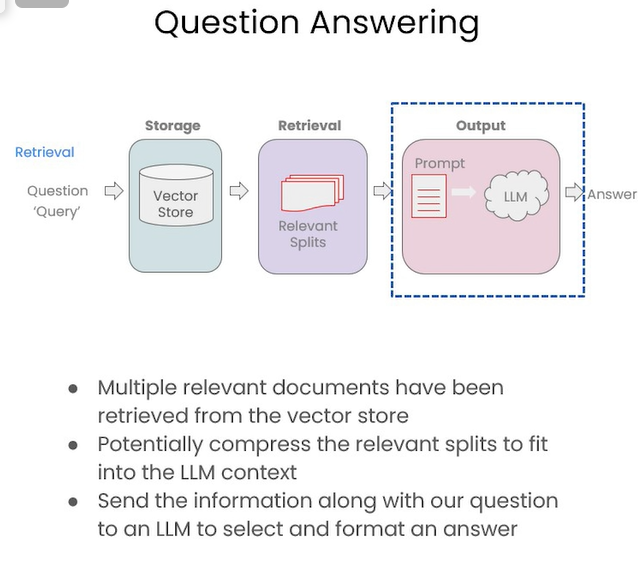

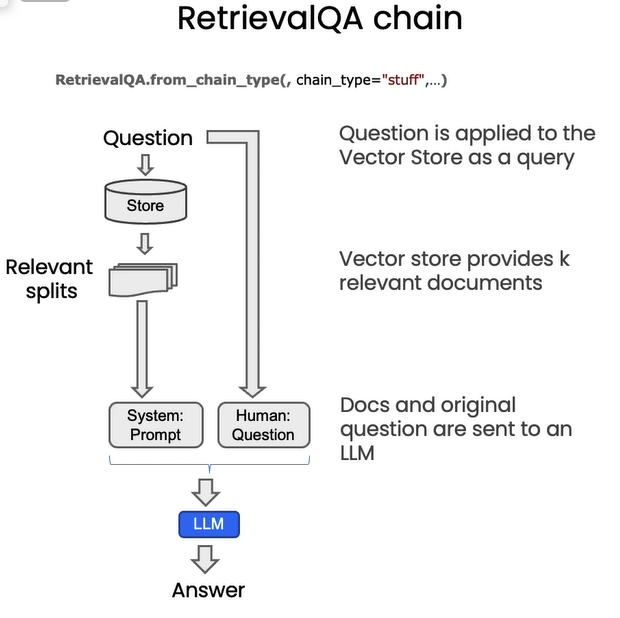

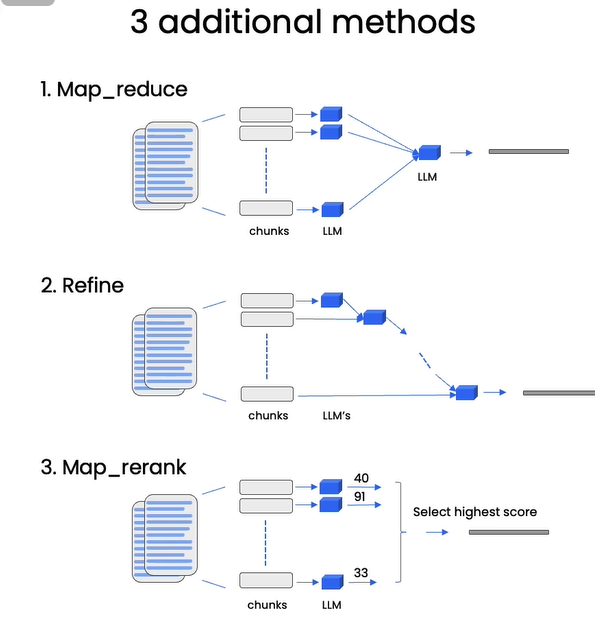

In [ ]:
import datetime
current_date = datetime.datetime.now().date()
if current_date < datetime.date(2023, 9, 2):
    llm_name = "gpt-3.5-turbo-0301"
else:
    llm_name = "gpt-3.5-turbo"
print(llm_name)

gpt-3.5-turbo-0301


In [ ]:
from langchain.vectorstores import Chroma
from langchain.embeddings.openai import OpenAIEmbeddings
persist_directory = 'docs/chroma/'
embedding = OpenAIEmbeddings()
vectordb = Chroma(persist_directory=persist_directory, embedding_function=embedding)

In [ ]:
print(vectordb._collection.count())

375


In [ ]:
question = "What are major topics for this class?"
docs = vectordb.similarity_search(question,k=3)
len(docs)

3

In [ ]:
from langchain.chat_models import ChatOpenAI
llm = ChatOpenAI(model_name=llm_name, temperature=0)

## RetrievalQA chain

In [ ]:
from langchain.chains import RetrievalQA
qa_chain = RetrievalQA.from_chain_type(
    llm,
    retriever=vectordb.as_retriever()
)

In [ ]:
result = qa_chain({"query": question})
result # result['result']

{'query': 'What are major topics for this class?',
 'result': 'The major topics for this class are supervised learning and deep learning. Under supervised learning, the topics covered are linear regression, classification and logistic regression, generalized linear models, generative learning algorithms, kernel methods, and support vector machines. Under deep learning, the topics covered are neural networks, modules in modern neural networks, and backpropagation.'}

In [ ]:
from langchain.prompts import PromptTemplate

# Build prompt
template = """Use the following pieces of context to answer the question at the end. If you don't know the answer, just say that you don't know, don't try to make up an answer. Use three sentences maximum. Keep the answer as concise as possible. Always say "thanks for asking!" at the end of the answer.
{context}
Question: {question}
Helpful Answer:"""
QA_CHAIN_PROMPT = PromptTemplate.from_template(template)


In [ ]:
# Run chain
qa_chain = RetrievalQA.from_chain_type(
    llm,
    retriever=vectordb.as_retriever(),
    return_source_documents=True,
    chain_type_kwargs={"prompt": QA_CHAIN_PROMPT}
)

In [ ]:
question = "Is probability a class topic?"

In [ ]:
result = qa_chain({"query": question})

In [ ]:
result["result"]

'Yes, probability is a class topic in the context of learning theory and classification algorithms. Thanks for asking!'

In [ ]:
result["source_documents"][0]

Document(page_content='127\ntimes and calculate the fraction of times that it came up heads, that will be\na good estimate of \x1ewith high probability (if nis large).\nUsing just these two lemmas, we will be able to prove some of the deepest\nand most important results in learning theory.\nTo simplify our exposition, let\'s restrict our attention to binary classi\x0cca-\ntion in which the labels are y2f0;1g. Everything we\'ll say here generalizes\nto other problems, including regression and multi-class classi\x0ccation.\nWe assume we are given a training set S=f(x(i);y(i));i= 1;:::;ngof size\nn, where the training examples ( x(i);y(i)) are drawn iid from some probability\ndistributionD. For a hypothesis h, we de\x0cne the training error (also called\ntheempirical risk orempirical error in learning theory) to be\n^"(h) =1\nnnX\ni=11fh(x(i))6=y(i)g:\nThis is just the fraction of training examples that hmisclassi\x0ces. When we\nwant to make explicit the dependence of ^ "(h) on the train

## RetrievalQA chain types

In [ ]:
qa_chain_mr = RetrievalQA.from_chain_type(
    llm,
    retriever=vectordb.as_retriever(),
    chain_type="map_reduce"
)

In [ ]:
result = qa_chain_mr({"query": question})

In [ ]:
result["result"]

'It is possible that probability is a class topic, but there is not enough information in the given portion of the document to confirm this. The text discusses probability in the context of Naive Bayes and text classification, but it does not provide enough context to determine if probability is a topic of the entire class.'

# Chat

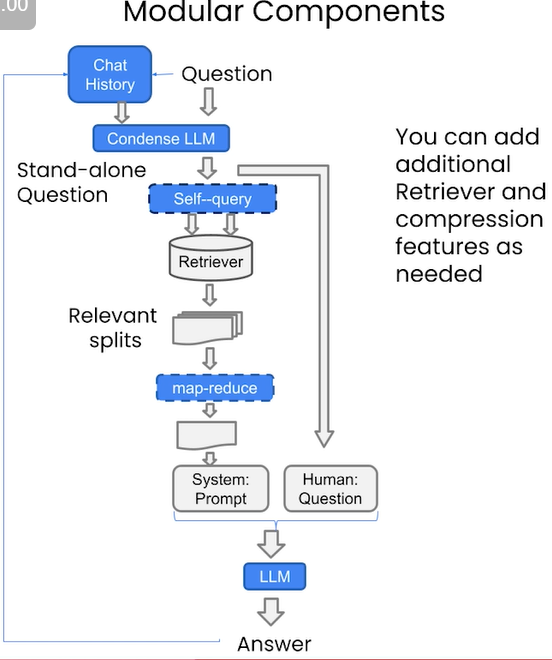

In [ ]:
import datetime
current_date = datetime.datetime.now().date()
if current_date < datetime.date(2023, 9, 2):
    llm_name = "gpt-3.5-turbo-0301"
else:
    llm_name = "gpt-3.5-turbo"
print(llm_name)

gpt-3.5-turbo-0301


In [ ]:
from langchain.vectorstores import Chroma
from langchain.embeddings.openai import OpenAIEmbeddings
persist_directory = 'docs/chroma/'
embedding = OpenAIEmbeddings()
vectordb = Chroma(persist_directory=persist_directory, embedding_function=embedding)

In [ ]:
question = "What are major topics for this class?"
docs = vectordb.similarity_search(question,k=3)
len(docs)

3

In [ ]:
from langchain.chat_models import ChatOpenAI
llm = ChatOpenAI(model_name=llm_name, temperature=0)
llm.predict("Hello world!")

'Hello there! How can I assist you today?'

In [ ]:
# Build prompt
from langchain.prompts import PromptTemplate
template = """Use the following pieces of context to answer the question at the end. If you don't know the answer, just say that you don't know, don't try to make up an answer. Use three sentences maximum. Keep the answer as concise as possible. Always say "thanks for asking!" at the end of the answer.
{context}
Question: {question}
Helpful Answer:"""
QA_CHAIN_PROMPT = PromptTemplate(input_variables=["context", "question"],template=template,)

# Run chain
from langchain.chains import RetrievalQA
question = "Is probability a class topic?"
qa_chain = RetrievalQA.from_chain_type(llm,
                                       retriever=vectordb.as_retriever(),
                                       return_source_documents=True,
                                       chain_type_kwargs={"prompt": QA_CHAIN_PROMPT})


result = qa_chain({"query": question})
result["result"]

'Yes, probability is a class topic in the context of learning theory and classification algorithms. Thanks for asking!'

In [ ]:
from langchain.memory import ConversationBufferMemory
memory = ConversationBufferMemory(
    memory_key="chat_history",
    return_messages=True
)

In [ ]:
from langchain.chains import ConversationalRetrievalChain
retriever=vectordb.as_retriever()
qa = ConversationalRetrievalChain.from_llm(
    llm,
    retriever=retriever,
    memory=memory
)

In [ ]:
question = "Is probability a class topic?"
result = qa({"question": question})

In [ ]:
result['answer']

'Yes, probability is a topic that is often taught in mathematics and statistics classes. It is also a fundamental concept in many other fields, such as physics, engineering, and computer science.'

In [ ]:
question = "why are those prerequesites needed?"
result = qa({"question": question})

In [ ]:
result['answer']

'The reason for needing prerequisites in fields that use probability as a fundamental concept is that probability theory is a highly mathematical subject that requires a strong foundation in mathematical concepts such as calculus, linear algebra, and statistics. Without a solid understanding of these prerequisites, it can be difficult to fully grasp the more advanced concepts in probability theory. Additionally, many applications of probability theory, such as in machine learning and data science, require a strong understanding of these mathematical concepts in order to effectively apply probability theory to real-world problems.'

## Create a chatbot that works on your documents

In [ ]:
from langchain.embeddings.openai import OpenAIEmbeddings
from langchain.text_splitter import CharacterTextSplitter, RecursiveCharacterTextSplitter
from langchain.vectorstores import DocArrayInMemorySearch
from langchain.document_loaders import TextLoader
from langchain.chains import RetrievalQA,  ConversationalRetrievalChain
from langchain.memory import ConversationBufferMemory
from langchain.chat_models import ChatOpenAI
from langchain.document_loaders import TextLoader
from langchain.document_loaders import PyPDFLoader

In [ ]:
def load_db(file, chain_type, k):
    # load documents
    loader = PyPDFLoader(file)
    documents = loader.load()
    # split documents
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=150)
    docs = text_splitter.split_documents(documents)
    # define embedding
    embeddings = OpenAIEmbeddings()
    # create vector database from data
    db = DocArrayInMemorySearch.from_documents(docs, embeddings)
    # define retriever
    retriever = db.as_retriever(search_type="similarity", search_kwargs={"k": k})
    # create a chatbot chain. Memory is managed externally.
    qa = ConversationalRetrievalChain.from_llm(
        llm=ChatOpenAI(model_name=llm_name, temperature=0),
        chain_type=chain_type,
        retriever=retriever,
        return_source_documents=True,
        return_generated_question=True,
    )
    return qa


In [ ]:
import panel as pn
import param

class cbfs(param.Parameterized):
    chat_history = param.List([])
    answer = param.String("")
    db_query  = param.String("")
    db_response = param.List([])

    def __init__(self,  **params):
        super(cbfs, self).__init__( **params)
        self.panels = []
        self.loaded_file = "docs/pdfs/machine-learning.pdf"
        self.qa = load_db(self.loaded_file,"stuff", 4)

    def call_load_db(self, count):
        if count == 0 or file_input.value is None:  # init or no file specified :
            return pn.pane.Markdown(f"Loaded File: {self.loaded_file}")
        else:
            file_input.save("temp.pdf")  # local copy
            self.loaded_file = file_input.filename
            button_load.button_style="outline"
            self.qa = load_db("temp.pdf", "stuff", 4)
            button_load.button_style="solid"
        self.clr_history()
        return pn.pane.Markdown(f"Loaded File: {self.loaded_file}")

    def convchain(self, query):
        if not query:
            return pn.WidgetBox(pn.Row('User:', pn.pane.Markdown("", width=600)), scroll=True)
        result = self.qa({"question": query, "chat_history": self.chat_history})
        self.chat_history.extend([(query, result["answer"])])
        self.db_query = result["generated_question"]
        self.db_response = result["source_documents"]
        self.answer = result['answer']
        self.panels.extend([
            pn.Row('User:', pn.pane.Markdown(query, width=600)),
            pn.Row('ChatBot:', pn.pane.Markdown(self.answer, width=600, style={'background-color': '#F6F6F6'}))
        ])
        inp.value = ''  #clears loading indicator when cleared
        return pn.WidgetBox(*self.panels,scroll=True)

    @param.depends('db_query ', )
    def get_lquest(self):
        if not self.db_query :
            return pn.Column(
                pn.Row(pn.pane.Markdown(f"Last question to DB:", styles={'background-color': '#F6F6F6'})),
                pn.Row(pn.pane.Str("no DB accesses so far"))
            )
        return pn.Column(
            pn.Row(pn.pane.Markdown(f"DB query:", styles={'background-color': '#F6F6F6'})),
            pn.pane.Str(self.db_query )
        )

    @param.depends('db_response', )
    def get_sources(self):
        if not self.db_response:
            return
        rlist=[pn.Row(pn.pane.Markdown(f"Result of DB lookup:", styles={'background-color': '#F6F6F6'}))]
        for doc in self.db_response:
            rlist.append(pn.Row(pn.pane.Str(doc)))
        return pn.WidgetBox(*rlist, width=600, scroll=True)

    @param.depends('convchain', 'clr_history')
    def get_chats(self):
        if not self.chat_history:
            return pn.WidgetBox(pn.Row(pn.pane.Str("No History Yet")), width=600, scroll=True)
        rlist=[pn.Row(pn.pane.Markdown(f"Current Chat History variable", styles={'background-color': '#F6F6F6'}))]
        for exchange in self.chat_history:
            rlist.append(pn.Row(pn.pane.Str(exchange)))
        return pn.WidgetBox(*rlist, width=600, scroll=True)

    def clr_history(self,count=0):
        self.chat_history = []
        return


## Chatbot

In [ ]:
cb = cbfs()

file_input = pn.widgets.FileInput(accept='.pdf')
button_load = pn.widgets.Button(name="Load DB", button_type='primary')
button_clearhistory = pn.widgets.Button(name="Clear History", button_type='warning')
button_clearhistory.on_click(cb.clr_history)
inp = pn.widgets.TextInput( placeholder='Enter text here…')

bound_button_load = pn.bind(cb.call_load_db, button_load.param.clicks)
conversation = pn.bind(cb.convchain, inp)

#jpg_pane = pn.pane.Image( './img/convchain.jpg')

tab1 = pn.Column(
    pn.Row(inp),
    pn.layout.Divider(),
    pn.panel(conversation,  loading_indicator=True, height=300),
    pn.layout.Divider(),
)
tab2= pn.Column(
    pn.panel(cb.get_lquest),
    pn.layout.Divider(),
    pn.panel(cb.get_sources ),
)
tab3= pn.Column(
    pn.panel(cb.get_chats),
    pn.layout.Divider(),
)
tab4=pn.Column(
    pn.Row( file_input, button_load, bound_button_load),
    pn.Row( button_clearhistory, pn.pane.Markdown("Clears chat history. Can use to start a new topic" )),
    pn.layout.Divider(),
  #  pn.Row(jpg_pane.clone(width=400))
)
dashboard = pn.Column(
    pn.Row(pn.pane.Markdown('# ChatWithYourData_Bot')),
    pn.Tabs(('Conversation', tab1), ('Database', tab2), ('Chat History', tab3),('Configure', tab4))
)
dashboard

Column
    [0] Row
        [0] Markdown(str)
    [1] Tabs
        [0] Column
            [0] Row
                [0] TextInput(placeholder='Enter text here…')
            [1] Divider()
            [2] ParamFunction(function, _pane=WidgetBox, height=300, loading_indicator=True)
            [3] Divider()
        [1] Column
            [0] ParamMethod(method, _pane=Column)
            [1] Divider()
            [2] ParamMethod(method, _pane=Str)
        [2] Column
            [0] ParamMethod(method, _pane=WidgetBox)
            [1] Divider()
        [3] Column
            [0] Row
                [0] FileInput(accept='.pdf')
                [1] Button(button_type='primary', name='Load DB')
                [2] ParamFunction(function, _pane=Markdown)
            [1] Row
                [0] Button(button_type='warning', name='Clear History')
                [1] Markdown(str)
            [2] Divider()

In [ ]:
%matplotlib inline
dashboard

Column
    [0] Row
        [0] Markdown(str)
    [1] Tabs
        [0] Column
            [0] Row
                [0] TextInput(placeholder='Enter text here…')
            [1] Divider()
            [2] ParamFunction(function, _pane=WidgetBox, height=300, loading_indicator=True)
            [3] Divider()
        [1] Column
            [0] ParamMethod(method, _pane=Column)
            [1] Divider()
            [2] ParamMethod(method, _pane=Str)
        [2] Column
            [0] ParamMethod(method, _pane=WidgetBox)
            [1] Divider()
        [3] Column
            [0] Row
                [0] FileInput(accept='.pdf')
                [1] Button(button_type='primary', name='Load DB')
                [2] ParamFunction(function, _pane=Markdown)
            [1] Row
                [0] Button(button_type='warning', name='Clear History')
                [1] Markdown(str)
            [2] Divider()